<a href="https://colab.research.google.com/github/ankitsingh435517/lichess-gpt/blob/main/lichess_gpt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
!sudo apt-get install zstd
!pip install chess

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
zstd is already the newest version (1.5.5+dfsg2-2build1.1).
0 upgraded, 0 newly installed, 0 to remove and 0 not upgraded.


In [10]:
!wget -qO- https://database.lichess.org/standard/lichess_db_standard_rated_2026-08.pgn.zst | zstd -d | head -n 500000 > games.pgn

In [11]:
!wc -l games.pgn

500000 games.pgn


In [12]:
import chess.pgn

games = []
with open('games.pgn', 'r', encoding='utf-8') as f:
  while game := chess.pgn.read_game(f):
    uci_moves = []
    board = game.board()

    for move in game.mainline_moves():
      uci_moves.append(move.uci())
      board.push(move)

    if uci_moves:
      games.append("".join(uci_moves))

In [13]:
len(set(games))

24832

Total Games:  24909
Total moves: 6705307
Average moves/game: 269.19213938737005
Total games: 24909
Unique games: 24832
Duplicates: 77
Duplicate rate: 0.0030912521578545515
 5 plies: 134 unique / 24,909 games
10 plies: 950 unique / 24,909 games
20 plies: 6,772 unique / 24,909 games
30 plies: 17,274 unique / 24,909 games
40 plies: 22,074 unique / 24,909 games
Min:  4
Max:  1064
Mean:  269.19213938737005
Median:  252.0
Std:  123.75801041205156


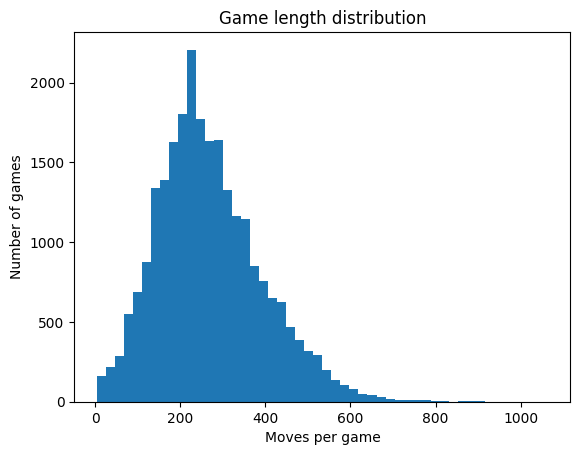

In [14]:
# Measure dataset
import numpy as np
import matplotlib.pyplot as plt

total_games = len(games)
total_moves = sum(len(game) for game in games)
lengths = np.array([len(game) for game in games])

print("Total Games: ", total_games)
print("Total moves:", total_moves)
print("Average moves/game:", total_moves / len(games))

game_strings = [
    " ".join(game)
    for game in games
]

unique_games = set(game_strings)

print("Total games:", len(game_strings))
print("Unique games:", len(unique_games))
print("Duplicates:", len(game_strings) - len(unique_games))

duplicate_rate = 1 - len(unique_games) / len(game_strings)

print("Duplicate rate:", duplicate_rate)

# check for variations in first N moves in each game
for n in [5, 10, 20, 30, 40]:
    prefixes = [tuple(game[:n]) for game in games]
    unique_prefixes = len(set(prefixes))

    print(
        f"{n:2d} plies: "
        f"{unique_prefixes:,} unique / {len(games):,} games"
    )

# distribution
print("Min: ", lengths.min())
print("Max: ", lengths.max())
print("Mean: ", lengths.mean())
print("Median: ", np.median(lengths))
print("Std: ", lengths.std())

plt.hist(lengths, bins=50)
plt.xlabel("Moves per game")
plt.ylabel("Number of games")
plt.title("Game length distribution")
plt.show()

In [ ]:
# build vocab
text = "".join(games)
chars = ['.'] + sorted(set(text))
vocab_size = len(chars)
stoi = {ch:i for i,ch in enumerate(chars)}
itos = {i:ch for i,ch in enumerate(chars)}
encode = lambda s: [stoi[ch] for ch in s]
decode = lambda l: "".join(itos[i] for i in l)

print(encode("e4"))
print(decode(encode("e4")))

[13, 4]
e4


In [ ]:
# tokenization - create a function which tokenizes into character level or BPE # train on both and check what is the different in training efficiency
# Character level tokenization

# compile dataset into train, eval and test split - 90, 5, 5 split
# the spit takes 90% of data to train due to the fact that the whole dataset is roughly 5000 games
# so 250 games to validate and test is sufficient enough and we need atleast 4000 games to train
import random
import torch

# shuffle the games to make the dataset represent overall structures of the games and avoid certain kinds of biased structures if there exists example similar openings in first few games etc
random.shuffle(games)

n1 = int(0.8*(len(games))) # 80%
n2 = int(0.9*len(games)) # 90%

context_size = 10

def compile_dataset(games):
  # compile the data into X and Y (X is the input sequence & Y is the corresponding output sequence)
  # we need context length of input for which output has to be stored e.g 3 for now so 3 moves input then we should expect 4th move as output
  X, Y = [], []
  for game in games:
    context = [0] * context_size # 0 0 0 -> meaning a '.' representing no move as in start of the game.
    for move in game + ".":
      ix = stoi[move]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix]

  return X, Y

def split_dataset(split="train"):
  # split
  data = {
      'train': games[:n1],
      'dev': games[n1:n2],
      'test': games[n2:]
  }[split]
  # compile
  X, Y = compile_dataset(data)
  X = torch.tensor(X)
  Y = torch.tensor(Y)
  return X, Y

Xtr, Ytr = split_dataset("train")
Xdev, Ydev = split_dataset("dev")
Xte, Yte = split_dataset("test")
print(Xtr.shape, Ytr.shape)
print(Xdev.shape, Ydev.shape)
print(Xte.shape, Yte.shape)

torch.Size([5386534, 10]) torch.Size([5386534])
torch.Size([668235, 10]) torch.Size([668235])
torch.Size([675447, 10]) torch.Size([675447])


In [ ]:
# create Embedding for inputs (token & position embedding - what & where)
# We need a shape of (vocab_size, embd_dim) so that we can pluck out examples batch like B, T, C # Batch, Token, Channel e.g 32, 3, 10 meaning 32 examples where each example has 3 chars as integers and each have 10 dimension vector to represent their vector embedding
import torch.nn as nn
import torch.nn.functional as F

g = torch.Generator().manual_seed(1337)

embd_size = vocab_size # small reasonable embedding capacity for a small model
embd_table = nn.Embedding(vocab_size, embd_size)

batch_size = 256 # standard 32 size of batch
h_dim = 600 # how many neurons in hidden layer

ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
x = Xtr[ix] # (32, 3)
y = Ytr[ix] # (32,)

emb = embd_table(x) # expecting 32, 3, 16 # B, T, C
B, T, C = emb.shape
emb = emb.view(B, T * C) # (32, 3 * 16)

# this emb input can now be fed into nn
hidden_layer = nn.Linear(T * C, h_dim) # (B, T * C) @ (T * C, h_dim) => (B, h_dim)
logit_layer = nn.Linear(h_dim, vocab_size) # (B, h_dim) @ (h_dim, V) => (B, V)

# apply layers - MLP
hidden = torch.relu(hidden_layer(emb)) # (B, h_dim)
logits = logit_layer(hidden) # shape expected: (B, V)

# find the loss of this batch
loss = F.cross_entropy(logits, y) # aggregated scalalr loss likelihood over all batch examples
print(loss)

tensor(2.9694, grad_fn=<NllLossBackward0>)


In [ ]:
# optimization
# all the parameters
lr = 3e-4
wd = 0.01
params = (
    list(embd_table.parameters())
    + list(hidden_layer.parameters())
    + list(logit_layer.parameters())
)
optimizer = torch.optim.Adam(params, lr=lr, weight_decay=wd)

In [ ]:
from math import inf

# Record the initial weights
before = logit_layer.weight.detach().clone()

train_lossi = []
dev_lossi = []
best_dev_loss = float("inf")

for step in range(10000):
    # batch sample
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    x = Xtr[ix] # (32, 3)
    y = Ytr[ix] # (32,)

    # forward pass
    emb = embd_table(x).reshape(x.shape[0], -1)
    hidden = torch.relu(hidden_layer(emb))
    logits = logit_layer(hidden)
    loss = F.cross_entropy(logits, y)

    # backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # print loss
    if step % 1000 == 0:
        print(loss.item())

    if step % 500 == 0:
      # compare the loss on entire train and val split
      @torch.no_grad()
      def evaluate(X, Y, split="Train"):
        emb = embd_table(X)
        emb = emb.reshape(emb.shape[0], -1)
        hidden = torch.relu(hidden_layer(emb))
        logits = logit_layer(hidden)
        return F.cross_entropy(logits, Y).item()

      train_loss = evaluate(Xtr, Ytr, "Train")
      train_lossi.append({
            "step": step,
            "loss": train_loss
      })
      eval_loss = evaluate(Xdev, Ydev, "dev")
      dev_lossi.append({
            "step": step,
            "loss": eval_loss
        })
      if eval_loss < best_dev_loss:
        # save the best loss as checkpoint
        torch.save({
            "step": step,
            "eval_loss": eval_loss,
            "embd_table": embd_table.state_dict(),
            "hidden_layer": hidden_layer.state_dict(),
            "logit_layer": logit_layer.state_dict()
        }, 'best_checkpoint.pt')
        print(f"Saved best checkpoint at step {step}, loss {eval_loss:.4f} ")
        best_dev_loss = eval_loss

after = logit_layer.weight.detach()
print("Weight change:", (after - before).norm().item())

2.9652390480041504


In [ ]:
# plot the losses
plt.plot([x["step"] for x in train_lossi], [x["loss"] for x in train_lossi], label="Train Loss")
plt.plot([x["step"] for x in dev_lossi], [x["loss"] for x in dev_lossi], label="Eval Loss")

plt.xlabel("Training steps")
plt.ylabel("Loss")
plt.title("Training loss vs. steps")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
best = min(dev_lossi, key=lambda x: x["loss"])

print("Best eval step:", best["step"])
print("Best eval loss:", best["loss"])

Best eval step: 2000
Best eval loss: 1.7579693794250488


In [ ]:
# load the model on best checkpoint
checkpoint = torch.load("best_checkpoint.pt", weights_only=True)

embd_table.load_state_dict(checkpoint["embd_table"])
hidden_layer.load_state_dict(checkpoint["hidden_layer"])
logit_layer.load_state_dict(checkpoint["logit_layer"])

print("Best step: ", checkpoint["step"])
print("Best eval loss: ", checkpoint["eval_loss"])

Best step:  2000
Best eval loss:  1.7579693794250488


In [ ]:
# eval - run loss on dev split
# batch sample
ix = torch.randint(0, Xdev.shape[0], (batch_size,), generator=g)
xd = Xdev[ix] # (32, 3)
yd = Ydev[ix] # (32,)

# forward pass
emb = embd_table(xd)
emb = emb.reshape(emb.shape[0], -1)
logits = logit_layer(torch.relu(hidden_layer(emb)))
loss = F.cross_entropy(logits, yd)
print(loss.item())

1.7461286783218384


In [ ]:
# Evaluate on the entire validation set
with torch.no_grad():
    emb = embd_table(Xdev)
    emb = emb.reshape(emb.shape[0], -1)

    hidden = torch.relu(hidden_layer(emb))
    logits = logit_layer(hidden)

    loss = F.cross_entropy(logits, Ydev)

print("Validation loss:", loss.item())

Validation loss: 1.7579693794250488


In [ ]:
# compare the loss on entire train and val split
@torch.no_grad()
def evaluate(X, Y):
    emb = embd_table(X)
    emb = emb.reshape(emb.shape[0], -1)
    hidden = torch.relu(hidden_layer(emb))
    logits = logit_layer(hidden)
    return F.cross_entropy(logits, Y).item()

print("Train loss:", evaluate(Xtr, Ytr))
print("Validation loss:", evaluate(Xdev, Ydev))

Train loss: 1.7382675409317017
Validation loss: 1.7579693794250488


In [ ]:
# inference - run generation on test split
@torch.no_grad()
def model(X):
  emb = embd_table(X)
  emb = emb.reshape(emb.shape[0], -1)
  hidden = torch.relu(hidden_layer(emb))
  logits = logit_layer(hidden)
  return logits

def generate(max_new_tokens=50):
  context = [0] * context_size
  out = []
  for _ in range(max_new_tokens):
    X = torch.tensor([context])
    logits = model(X)
    probs = F.softmax(logits, dim=-1)
    next_id = torch.multinomial(probs, num_samples=1)
    tok_id = next_id.item()
    out.append(tok_id)
    context = context[1:] + [tok_id]

    if tok_id == 0:
      break

  return out

print(decode(generate(50)))

g2gea3c25132d1e1f1f1d4e4c1e4e7f6e2d3d8e8f1d1d8d6d2


In [ ]:
# Add the plots for losses digression while training for train and eval
# --------
# Write the full uci move tokenization
# Train the MLP on the full uci move tokenization
# Compare the losses of char level vs full uci move tokenization losses (train model based on tokenization passed)
# --------
# Write the transformer self attention decoder only
# Train the transformer on full uci move tokenization on larger dataset of 1k games
# Compare losses on MLP vs transformer
# -------
# Start the experiment on mech interp.
# -------
# Move the code to vscode
# Write up